In [7]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os, sys
from pathlib import Path
import functools

import extra.data as ex
from extra.components import XGM
from extra.components import XrayPulses
from extra.data.components import JUNGFRAU
from extra.data import by_index
import extra_speckle as esp
from extra_speckle.setup import Setup

from dask_jobqueue import SLURMCluster
from dask.distributed import Client
import dask.array as da

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py
import pyFAI
import fabio

from analysis.agipd_integrate import (
    _ai,
    GEOM_PATH,
    MASK_PATH,
    SDD_MM,
    WAVELENGTH_M,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
PROPOSAL, RUN_NO = 10400, 423

In [9]:
JF_MASK1 = "/gpfs/exfel/u/usr/MID/202601/p010400/masks/jf1_mask.edf"
JF_MASK2 = "/gpfs/exfel/u/usr/MID/202601/p010400/masks/jf2_mask.edf"

In [11]:
def load_cube_jf(
    run_no: int, proposal: int, detector_id: int, train_idxs: slice = np.s_[0]
) -> xr.DataArray:
    if detector_id not in [1, 2]:
        raise ValueError(f"detector_id can only be 1 or 2, you entered: {detector_id}")
    run = ex.open_run(run=run_no, proposal=proposal, data="proc")
    data = (
        JUNGFRAU(run, detector_name=f"MID_EXP_JF500K{detector_id}")
        .select_trains(train_idxs)
        .get_array("data.adc")
        .squeeze("module")
    )
    mask = (
        JUNGFRAU(run, detector_name=f"MID_EXP_JF500K{detector_id}")
        .select_trains(train_idxs)
        .get_array("data.mask")
        .squeeze("module")
    )
    data.data[mask.data > 0] = np.nan
    return data


def load_mean_img_jf(
    run_no: int, proposal: int, detector_id: int, train_idxs: slice = np.s_[0]
) -> np.ndarray:
    data = load_cube_jf(run_no, proposal, detector_id, train_idxs)
    mean_image = data.mean(["train", "cell"], skipna=True)
    return mean_image.data.copy()


def match_curves(
    q_ref: np.ndarray,
    i_ref: np.ndarray,
    q_scale: np.ndarray,
    i_scale: np.ndarray,
    n_overlap: int = 200,
    trim: float = 0.1,
    merge: bool = True,
    dq: float | None = None,
) -> tuple[np.ndarray, float] | tuple[np.ndarray, np.ndarray, float]:
    """Scale ``i_scale`` by a single factor to match ``i_ref`` in their overlap.

    Args:
        q_ref, i_ref: reference curve (kept fixed).
        q_scale, i_scale: curve to be rescaled.
        n_overlap: number of points on the shared grid used to fit the factor.
        trim: fraction of the overlap dropped from each end before fitting,
            to avoid the noisy module edges.
        merge: if True, also stitch both curves into one on a common q axis.
        dq: q-spacing of the merged grid. Defaults to the finer of the two
            curves' median spacings.

    Returns:
        If ``merge`` is False: ``(i_scaled, factor)`` with ``i_scaled = i_scale * factor``.
        If ``merge`` is True: ``(q_merged, i_merged, factor)``.
    """
    lo = max(q_ref.min(), q_scale.min())
    hi = min(q_ref.max(), q_scale.max())
    if lo >= hi:
        raise ValueError("curves do not overlap in q")

    # --- fit the multiplicative factor over the trimmed overlap ---
    pad = trim * (hi - lo)
    grid = np.linspace(lo + pad, hi - pad, n_overlap)
    a = np.interp(grid, q_ref, i_ref)
    b = np.interp(grid, q_scale, i_scale)
    factor = float(np.median(a / b))
    i_scaled = i_scale * factor

    if not merge:
        return i_scaled, factor

    # --- stitch onto a common q axis ---
    # identify which curve extends to lower / higher q
    if q_scale.min() <= q_ref.min():
        q_lo, i_lo, q_hi, i_hi = q_scale, i_scaled, q_ref, i_ref
    else:
        q_lo, i_lo, q_hi, i_hi = q_ref, i_ref, q_scale, i_scaled

    if dq is None:
        dq = float(min(np.median(np.diff(q_ref)), np.median(np.diff(q_scale))))

    q_merged = np.arange(
        min(q_ref.min(), q_scale.min()),
        max(q_ref.max(), q_scale.max()),
        dq,
    )

    # interpolate each curve, marking outside its own range as NaN
    lo_i = np.interp(q_merged, q_lo, i_lo, left=np.nan, right=np.nan)
    hi_i = np.interp(q_merged, q_hi, i_hi, left=np.nan, right=np.nan)

    # linear cross-fade weight toward the higher-q curve across the overlap
    w = np.clip((q_merged - lo) / (hi - lo), 0.0, 1.0)

    i_merged = np.empty_like(q_merged)
    both = ~np.isnan(lo_i) & ~np.isnan(hi_i)
    only_lo = ~np.isnan(lo_i) & np.isnan(hi_i)
    only_hi = np.isnan(lo_i) & ~np.isnan(hi_i)
    i_merged[only_lo] = lo_i[only_lo]
    i_merged[only_hi] = hi_i[only_hi]
    i_merged[both] = (1.0 - w[both]) * lo_i[both] + w[both] * hi_i[both]

    # drop any grid points not covered by either curve
    covered = both | only_lo | only_hi
    return q_merged[covered], i_merged[covered], factor


class WAXSIntegrator:
    def __init__(
        self,
        run_no: int,
        proposal: int,
        mask1: np.ndarray,
        mask2: np.ndarray,
        ai1: pyFAI.integrator,
        ai2: pyFAI.integrator,
    ):
        self.run_no = run_no
        self.proposal = proposal
        self.mask1 = mask1.astype(np.float32)
        self.mask2 = mask2.astype(np.float32)
        self.ai1 = ai1
        self.ai2 = ai2

    def _load(self, train_idxs: slice = np.s_[0]) -> tuple[np.ndarray, np.ndarray]:
        data1 = load_mean_img_jf(self.run_no, self.proposal, 1, train_idxs)
        data2 = load_mean_img_jf(self.run_no, self.proposal, 2, train_idxs)
        data1[self.mask1 > 0] = np.nan
        data2[self.mask2 > 0] = np.nan
        return data1, data2

    def _load_cube(self, train_idxs: slice = np.s_[0]) -> tuple[np.ndarray, np.ndarray]:
        data1 = load_cube_jf(self.run_no, self.proposal, 1, train_idxs)
        data2 = load_cube_jf(self.run_no, self.proposal, 2, train_idxs)
        _mask3d1 = np.broadcast_to(self.mask1 > 0.3, data1.shape)
        data1.data[_mask3d1 > 0] = np.nan
        _mask3d2 = np.broadcast_to(self.mask2 > 0.3, data2.shape)
        data2.data[_mask3d2 > 0] = np.nan
        return data1, data2

    def integrate(
        self, train_idxs: slice = np.s_[0], **kwargs
    ) -> tuple[np.ndarray, np.ndarray]:
        data1, data2 = self._load(train_idxs)
        q1, iq1 = ai1.integrate1d(data1, npt=100)
        q1 = q1[iq1 > 0][1:-1]
        iq1 = iq1[iq1 > 0][1:-1]
        q2, iq2 = ai2.integrate1d(data2, npt=100)
        q2 = q2[iq2 > 0][1:-1]
        iq2 = iq2[iq2 > 0][1:-1]
        q, iq, _ = match_curves(q2, iq2, q1, iq1, **kwargs)
        return q, iq

In [12]:
mask1 = fabio.open(JF_MASK1).data
mask2 = fabio.open(JF_MASK2).data
ai1 = pyFAI.load("/gpfs/exfel/u/usr/MID/202601/p010400/geometry/jf1.poni")
ai2 = pyFAI.load("/gpfs/exfel/u/usr/MID/202601/p010400/geometry/jf2.poni")

colors = plt.cm.viridis(np.linspace(0, 1, len(range(0, 3000, 500))))

waxs_bg = WAXSIntegrator(57, PROPOSAL, mask1, mask2, ai1, ai2)
q, iq_bg = waxs_bg.integrate(train_idxs=np.s_[50:100], n_overlap=100, trim=0.5)

# for r in range(423, 433):
#     waxs = WAXSIntegrator(r, PROPOSAL, mask1, mask2, ai1, ai2)
#     q, iq = waxs.integrate(train_idxs=np.s_[::200], n_overlap=100, trim=0.8)
#     plt.plot(q, iq)
# plt.show()

# waxs = WAXSIntegrator(423, PROPOSAL, mask1, mask2, ai1, ai2)
# d1, d2 = waxs._load_cube(train_idxs=np.s_[::100])

In [13]:
waxs_bg = WAXSIntegrator(57, PROPOSAL, mask1, mask2, ai1, ai2)
d1, d2 = waxs_bg._load(train_idxs=np.s_[50:100])

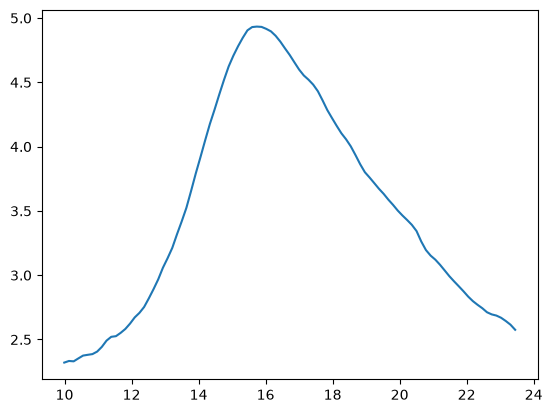

In [28]:
plt.plot(q, iq_bg)